Function implementation

In [1]:
import networkx as nx
import pandas as pd
from scipy.stats import kendalltau
#loading the dataset
G = nx.karate_club_graph()
#calculating other centrality measures to later create the correlation matrix
degree = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G)
closeness = nx.closeness_centrality(G)
eigenvector = nx.eigenvector_centrality(G)

#function to calculate leverage centrality
def leverage_centrality(G):
    LC = {}                                        #dictionary that will store the node and its leverage centrality
    degree = dict(G.degree())                      #first, calculating degree of each node

    for node in G.nodes():                         #loop that calculates the leverage centrality of each node iteratively
        k_i = degree[node]

        if k_i == 0:                               #if the node is disconnected(degree is 0), then its leverage centrality is 0
            LC[node] = 0
            continue

        total = 0

        for neighbor in G.neighbors(node):         #loop that calculates the degree of the neighbors of the current selected node
            k_j = degree[neighbor]
            total += (k_i - k_j) / (k_i + k_j)

        LC[node] = total / k_i                     #finally calculating the leverage centrality of the selected node

    return LC


leverage = leverage_centrality(G)

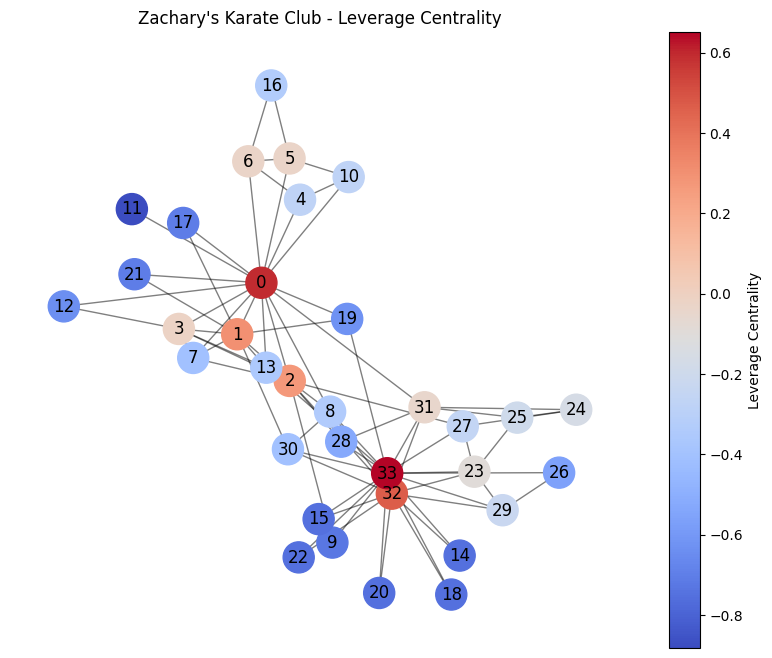

In [3]:
# Visualize Zachary's Karate Club using Leverage Centrality
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G, seed=42)

nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_color=list(leverage.values()),
    cmap="coolwarm",
    node_size=500
)

nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos)

plt.colorbar(nodes, label="Leverage Centrality")
plt.title("Zachary's Karate Club - Leverage Centrality")
plt.axis("off")
plt.show()

In [4]:
#testing whether leverage centrality does show some different insight in the karate dataset
centralities = {
    "Degree": degree,
    "Closeness": closeness,
    "Betweenness": betweenness,
    "Eigenvector": eigenvector,
    "Leverage": leverage
}

for name, values in centralities.items():
    top5 = sorted(values.items(), key=lambda x: x[1], reverse=True)[:5]
    print(name)
    print([node for node, value in top5])
    print()

Degree
[33, 0, 32, 2, 1]

Closeness
[0, 2, 33, 31, 8]

Betweenness
[0, 33, 32, 2, 31]

Eigenvector
[33, 0, 2, 32, 1]

Leverage
[33, 0, 32, 1, 2]



The above analysis revealed a difference that was not observed in the other centrality rankings. Leverage Centrality ranked node 1 fourth, whereas node 1 did not appear in the top five for the other measures. Although Degree Centrality showed that node 2 has a higher degree than node 1, Leverage Centrality ranked node 2 lower than node 1. This shows that a higher degree does not necessarily result in a higher Leverage Centrality, since Leverage Centrality also considers the degrees of a node's immediate neighbors.

In [5]:
centrality_df = pd.DataFrame({
    "Degree": pd.Series(degree),
    "Closeness": pd.Series(closeness),
    "Betweenness": pd.Series(betweenness),
    "Eigenvector": pd.Series(eigenvector),
    "Leverage": pd.Series(leverage)
})

Correlation matrices

In [6]:
pearson = centrality_df.corr(method="pearson")

print("Pearson Correlation Matrix")
print(pearson.round(4))

Pearson Correlation Matrix
             Degree  Closeness  Betweenness  Eigenvector  Leverage
Degree       1.0000     0.7716       0.9146       0.9173    0.8956
Closeness    0.7716     1.0000       0.7179       0.9046    0.6273
Betweenness  0.9146     0.7179       1.0000       0.8032    0.7473
Eigenvector  0.9173     0.9046       0.8032       1.0000    0.7444
Leverage     0.8956     0.6273       0.7473       0.7444    1.0000


In [7]:
spearman = centrality_df.corr(method="spearman")

print("Spearman Rank Correlation Matrix")
print(spearman.round(4))

Spearman Rank Correlation Matrix
             Degree  Closeness  Betweenness  Eigenvector  Leverage
Degree       1.0000     0.8945       0.9049       0.7766    0.8823
Closeness    0.8945     1.0000       0.8980       0.8564    0.6749
Betweenness  0.9049     0.8980       1.0000       0.6939    0.8089
Eigenvector  0.7766     0.8564       0.6939       1.0000    0.4468
Leverage     0.8823     0.6749       0.8089       0.4468    1.0000


In [8]:
kendall = centrality_df.corr(method="kendall")

print("Kendall's Tau Correlation Matrix")
print(kendall.round(4))

Kendall's Tau Correlation Matrix
             Degree  Closeness  Betweenness  Eigenvector  Leverage
Degree       1.0000     0.7863       0.8097       0.6528    0.7708
Closeness    0.7863     1.0000       0.7725       0.6927    0.5186
Betweenness  0.8097     0.7725       1.0000       0.5554    0.6631
Eigenvector  0.6528     0.6927       0.5554       1.0000    0.3504
Leverage     0.7708     0.5186       0.6631       0.3504    1.0000
